# Projections and orthogonalisations Code Challenges and Solutions to Practice Questions

# Playing around with showing projections

[ -5 -10]
[-7 -7]
[-4.2 -8.4]


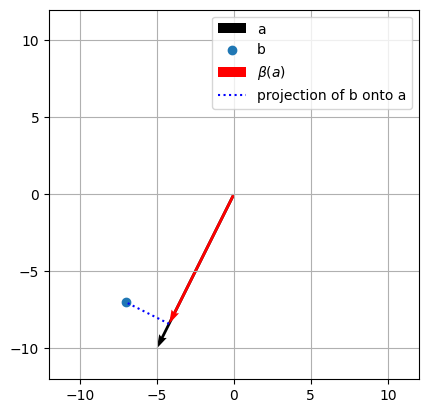

In [82]:
import numpy as np
import matplotlib.pyplot as plt

a = np.random.randint(-10, 10, 2)
print(a)

b = np.random.randint(-10, 10, 2)
print(b)

beta = (a.T @ b) / (a.T @ a)

beta_a = beta * a
print(beta_a)

plt.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, label="a")
plt.scatter(b[0], b[1], label="b")
plt.quiver(
    0,
    0,
    beta_a[0],
    beta_a[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="r",
    label=r"$\beta (a)$",
)
plt.plot(
    [beta_a[0], b[0]],
    [beta_a[1], b[1]],
    linestyle=":",
    color="blue",
    label="projection of b onto a",
)
plt.xlim(-12, 12)
plt.ylim(-12, 12)
plt.grid()
plt.legend()
plt.gca().set_aspect("equal")
plt.show()

## Code Challenge 1: Decompose vector into orthogonal components

- Vector w, to be decomposed $[2,3]$
- Vector v, the reference $[4,30]$
- Compute w parallel to v
- Compute w orthogonal to v
- Confirm results algebraically (sum orthogonal components to w)
- Plot all four vectors

[2. 0.]
[0. 3.]
[2. 3.]


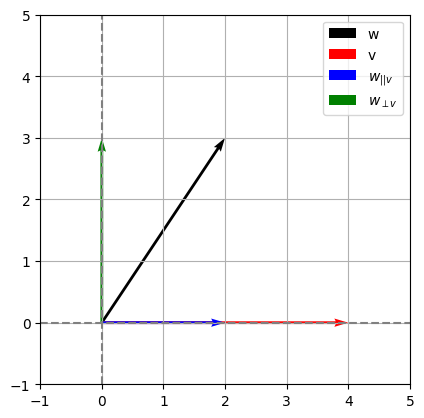

In [113]:
import matplotlib.pyplot as plt

# Vectors w and v
w = np.array([2, 3])
v = np.array([4, 0])

# Compute component of w parallel to v
par_w = (v.T @ w) / (v.T @ v) * v
print(par_w)

# Compute component of w perpendicular to v
perp_w = w.T - par_w
print(perp_w)

sum_w = par_w + perp_w
print(sum_w)

# Plot all components of W
plt.grid()
plt.axhline(color="grey", linestyle="--")
plt.axvline(color="grey", linestyle="--")
plt.quiver(0, 0, w[0], w[1], angles="xy", scale_units="xy", scale=1, label="w")
plt.quiver(
    0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color="r", label="v"
)
plt.quiver(
    0,
    0,
    par_w[0],
    par_w[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="b",
    label=r"$w_{||v}$",
)
plt.quiver(
    0,
    0,
    perp_w[0],
    perp_w[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="green",
    label=r"$w_{\perp v}$",
)
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.legend()
plt.gca().set_aspect("equal")
plt.show()

## Code Challenge 2: Implement the G-S procedure

- Start with a square matrix
- Compute Q using the Gram-Schmidt procedure
- Check $Q^TQ = I$
- Compare result with QR decomposition (signs could flip, could calculate abs())
- Make sure it also works with rectangular matrices

In [ ]:
# Define matrix dimensions
m = 4
n = 2

# Create random matrix A
A = np.random.randint(0, 10, (m, n))
print(A)

Q = np.empty([m, n])
for i in range(n):
    if i == 0:
        Q[:, i] = A[:, i] / np.sqrt(np.dot(A[:, 0], A[:, 0]))

    else:
        Q[:, i] = A[:, i]
        for j in range(i):

            Q[:, i] = Q[:, i] - (
                (np.dot(Q[:, j], A[:, i]) / np.dot(Q[:, j], Q[:, j])) * Q[:, j]
            )
        Q[:, i] = Q[:, i] / np.sqrt(np.dot(Q[:, i], Q[:, i]))

print(Q)

Q_R, R = np.linalg.qr(A)
print(Q_R)

print(np.round(abs(Q) - abs(Q_R)))

[[9 4]
 [2 1]
 [7 6]
 [7 2]]
[[ 0.66529914 -0.21100802]
 [ 0.14784425 -0.00925474]
 [ 0.51745489  0.81441692]
 [ 0.51745489 -0.54047668]]
[[-0.66529914  0.21100802]
 [-0.14784425  0.00925474]
 [-0.51745489 -0.81441692]
 [-0.51745489  0.54047668]]
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [ ]:
# Same thing as above, but trying to be more pythonic

# Define matrix dimensions
m, n = 4, 4
# Create random matrix A
A = np.random.randint(0, 10, (m, n))


Q = np.empty_like(A)

for i, col in enumerate(
    A.T
):  # loop over i, and return each row (which is each column given the transpose)
    v = col.copy()  # copy current column of A
    if i > 0:  # for every loop other than the first

        # Vectorised version of the mult: combine all previous
        # orthogonalised columns of Q into a matrix
        # and use that to mult with current v
        proj = Q[:, :i] @ (Q[:, :i].T @ v)
        v -= proj  # operator to subtract the projection from v

    Q[:, i] = v / np.linalg.norm(v)  # normalise the orthogonalised vector

print("Q.T @ Q:\n", np.round(Q.T @ Q, 6))

Q.T @ Q:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


## Code Challenge 3: Calculate the matrix inverse via Q-R decomposition

- Generate a large matrix (n=100)
- Invert it twice using Q-R decomposition
- Invert it using the np.linalg.inv() function

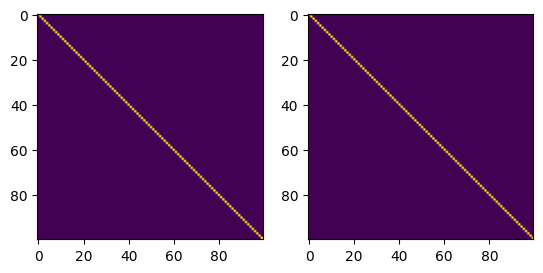

Correlation between QR inverse and numpy inverse:
 [[1. 1.]
 [1. 1.]]


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 100 x 100 matrix
A = np.random.randn(100, 100)

# Calculate inverse using Q-R Decomposition
# A^-1 = Q^T @ R^-1
Q, R = np.linalg.qr(A)
QR_inv_A = np.linalg.inv(R) @ Q.T

# Better version is to use np.linalg.solve() which is more numerically stable than np.linalg.inv():
QR_inv_A = np.linalg.solve(R, Q.T)

# Calulate inverse using np.linalg.inv()
inv_A = np.linalg.inv(A)

# print("A_inv_QR @ A:\n", np.round(QR_inv_A @ A))
# print("A_inv_np @ A:\n", inv_A @ A)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(QR_inv_A @ A)
axes[1].imshow(inv_A @ A)
plt.show()

flattened_QR_inv_A = QR_inv_A.flatten()
flattened_inv_A = inv_A.flatten()

print(
    "Correlation between QR inverse and numpy inverse:\n",
    np.corrcoef(flattened_QR_inv_A, flattened_inv_A),
)

## Code Challenge 4: Sherman-Morrison inverse

- Create an example of the Sherman-Morrison inverse
- Show a failure case

In [158]:
# Working case

# Define vector and I sizes
n = 5

# Generate two random vectors
a = np.random.randint(0, 10, n)
b = np.random.randint(0, 10, n)

print(a)
print(b)

# A = I - ab^T
A = np.eye(n) - (np.linalg.outer(a, b))

# A_inv = I + ab^T / 1 - a^Tb
A_inv = np.eye(n) + np.linalg.outer(a, b) / (1 - np.dot(a, b))

# Multiply for the identity matrix
I = A @ A_inv

print(np.round(I))

[0 6 4 0 1]
[6 2 9 3 5]
[[ 1.  0.  0.  0.  0.]
 [ 0.  1. -0.  0.  0.]
 [ 0.  0.  1.  0. -0.]
 [ 0.  0.  0.  1.  0.]
 [ 0.  0.  0. -0.  1.]]


In [243]:
# Failure case

# Define vector and I sizes
n = 5

# Generate random vector a
a = np.random.randint(0, 10, n)
a = a / np.linalg.norm(a)  # normalise a to make it a unit vector

# Generate vector b as a scaled version of a
b = np.copy(a) * np.random.rand()
b = b / np.linalg.norm(b)  # normalise b to make it a unit vector

print(np.dot(a, b))

print(a)
print(b)

# A = I - ab^T
A = np.eye(n) - (np.linalg.outer(a, b))

# A_inv = I + ab^T / 1 - a^Tb
A_inv = np.eye(n) + np.linalg.outer(a, b) / (1 - np.round(np.dot(a, b), 3))

# Multiply for the identity matrix
I = A @ A_inv

print(np.round(I))

1.0
[0.77777778 0.44444444 0.         0.44444444 0.        ]
[0.77777778 0.44444444 0.         0.44444444 0.        ]
[[nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]]


/var/folders/6x/_9kyqs096vv_xhnb0sfv30z80000gn/T/ipykernel_45041/1101636374.py:23: RuntimeWarning: divide by zero encountered in divide
  A_inv = np.eye(n) + np.linalg.outer(a, b) / (1 - np.round(np.dot(a, b), 3))
/var/folders/6x/_9kyqs096vv_xhnb0sfv30z80000gn/T/ipykernel_45041/1101636374.py:23: RuntimeWarning: invalid value encountered in divide
  A_inv = np.eye(n) + np.linalg.outer(a, b) / (1 - np.round(np.dot(a, b), 3))
/var/folders/6x/_9kyqs096vv_xhnb0sfv30z80000gn/T/ipykernel_45041/1101636374.py:26: RuntimeWarning: invalid value encountered in matmul
  I = A @ A_inv


## Code Challenge 5: Show that $A^TA = R^TR$

- Generate random matrix A
- Compute QR decompostion
- Test the claim
- Proove on paper/pen

In [ ]:
import numpy as np

# Define size of matrix n
n = 8

# Generate random matrix A
A = np.random.randn(n, n)

# Compute QR decomp of matrix A
Q, R = np.linalg.qr(A)

# See if they are the same
ATA = A.T @ A

RTR = R.T @ R

print(np.round(ATA - RTR))

[[ 0. -0. -0.  0.  0.  0. -0.  0.]
 [-0. -0.  0. -0.  0. -0.  0. -0.]
 [-0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -0.  0. -0. -0.  0.  0.  0.]
 [ 0.  0.  0. -0. -0.  0. -0.  0.]
 [ 0. -0.  0.  0.  0. -0.  0. -0.]
 [-0.  0.  0.  0. -0.  0. -0.  0.]
 [ 0. -0.  0.  0.  0. -0.  0. -0.]]
[[ 1.  0.  0.  0.  0.  0.  0. -0.]
 [ 0.  1.  0. -0.  0. -0. -0. -0.]
 [ 0.  0.  1. -0.  0. -0. -0.  0.]
 [ 0. -0. -0.  1. -0.  0.  0. -0.]
 [ 0.  0.  0. -0.  1. -0.  0.  0.]
 [ 0. -0. -0.  0. -0.  1.  0. -0.]
 [ 0. -0. -0.  0.  0.  0.  1. -0.]
 [-0. -0.  0. -0.  0. -0. -0.  1.]]
